# Project — Chapter 84: Logistic Growth Simulation

> **Prerequisites:** ch064 (Sigmoid), ch076 (Dynamical Systems), ch078 (Simulation)
>
> **Concepts:** Logistic map, carrying capacity, discrete vs continuous, bifurcations
>
> **Output:** Complete parameter sweep with bifurcation diagram and comparison to continuous model
>
> **Difficulty:** Intermediate | ~45 minutes

---

## Stage 1 — Discrete Logistic Map

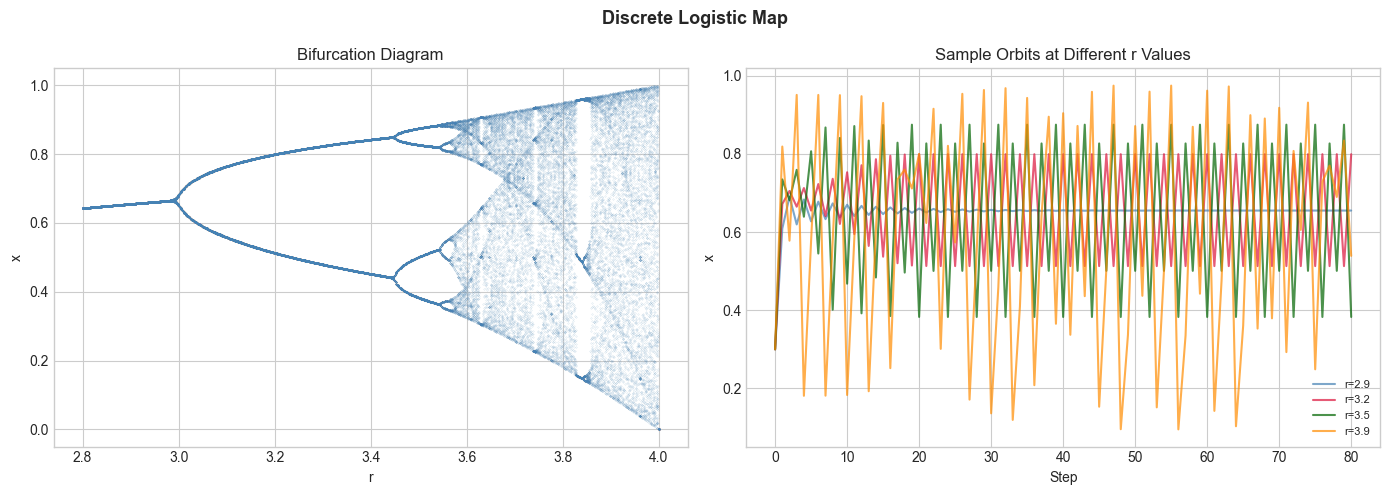

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Discrete logistic map: xₙ₊₁ = r*xₙ*(1-xₙ)
def logistic_orbit(x0, r, n=200):
    orbit = [x0]
    x = x0
    for _ in range(n):
        x = r * x * (1 - x)
        orbit.append(x)
    return np.array(orbit)

# Bifurcation diagram
r_vals = np.linspace(2.8, 4.0, 800)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bif_r, bif_x = [], []
for r in r_vals:
    orbit = logistic_orbit(0.5, r, 300)
    tail = orbit[-80:]
    bif_r.extend([r]*80)
    bif_x.extend(tail.tolist())

axes[0].scatter(bif_r, bif_x, s=0.03, color='steelblue', alpha=0.4)
axes[0].set_title('Bifurcation Diagram'); axes[0].set_xlabel('r'); axes[0].set_ylabel('x')

# Example orbits
for r_ex, color in [(2.9,'steelblue'),(3.2,'crimson'),(3.5,'darkgreen'),(3.9,'darkorange')]:
    orbit = logistic_orbit(0.3, r_ex, 80)
    axes[1].plot(orbit, color=color, linewidth=1.5, alpha=0.7, label=f'r={r_ex}')
axes[1].set_title('Sample Orbits at Different r Values')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('x'); axes[1].legend(fontsize=8)
plt.suptitle('Discrete Logistic Map', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Continuous Logistic Growth

C:\Users\user\AppData\Local\Temp\ipykernel_8280\1106643147.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


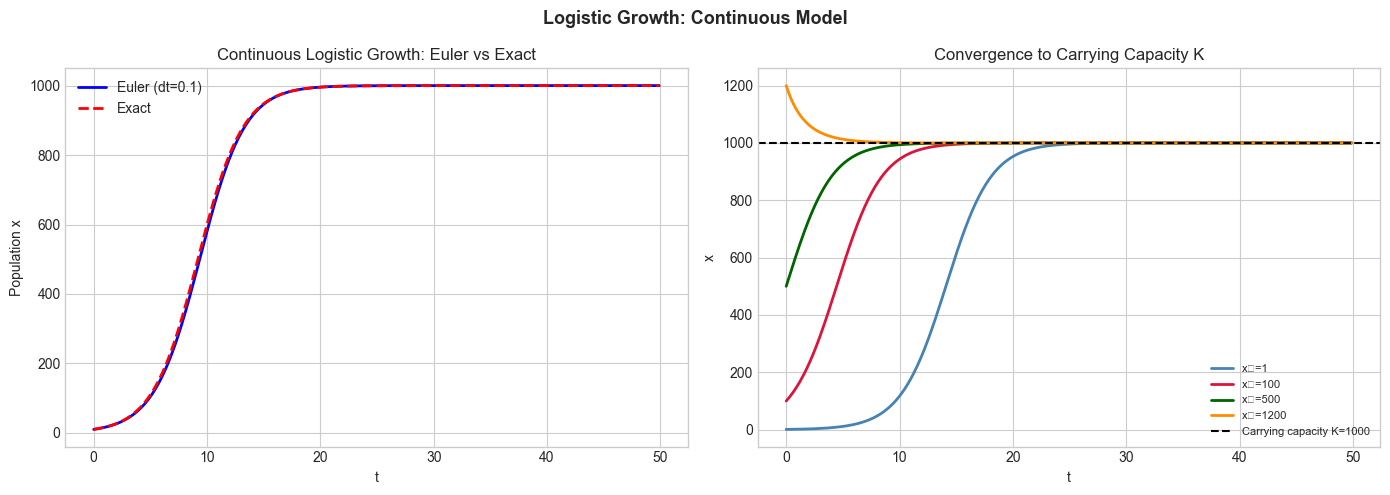

In [2]:
# Continuous logistic ODE: dx/dt = r*x*(1 - x/K)
def logistic_ode(x0, r, K, t_max=50, dt=0.1):
    ts = np.arange(0, t_max, dt)
    xs = [x0]
    x = float(x0)
    for _ in ts[1:]:
        x += r * x * (1 - x/K) * dt
        xs.append(x)
    return ts, np.array(xs)

# Analytical solution: x(t) = K / (1 + ((K-x0)/x0)*e^(-rt))
def logistic_exact(x0, r, K, t):
    return K / (1 + ((K - x0)/x0) * np.exp(-r * t))

# Compare Euler vs exact
x0, r, K = 10, 0.5, 1000
t_num, x_num = logistic_ode(x0, r, K)
x_exact = logistic_exact(x0, r, K, t_num)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_num, x_num, 'b-', linewidth=2, label='Euler (dt=0.1)')
axes[0].plot(t_num, x_exact, 'r--', linewidth=2, label='Exact')
axes[0].set_title('Continuous Logistic Growth: Euler vs Exact')
axes[0].set_xlabel('t'); axes[0].set_ylabel('Population x'); axes[0].legend()

# Multiple initial conditions
for x0_try, color in [(1,'steelblue'),(100,'crimson'),(500,'darkgreen'),(1200,'darkorange')]:
    t_n, x_n = logistic_ode(x0_try, r, K)
    axes[1].plot(t_n, x_n, color=color, linewidth=2, label=f'x₀={x0_try}')
axes[1].axhline(K, color='black', linestyle='--', label=f'Carrying capacity K={K}')
axes[1].set_title('Convergence to Carrying Capacity K'); axes[1].legend(fontsize=8)
axes[1].set_xlabel('t'); axes[1].set_ylabel('x')
plt.suptitle('Logistic Growth: Continuous Model', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 3 — Real Data Comparison

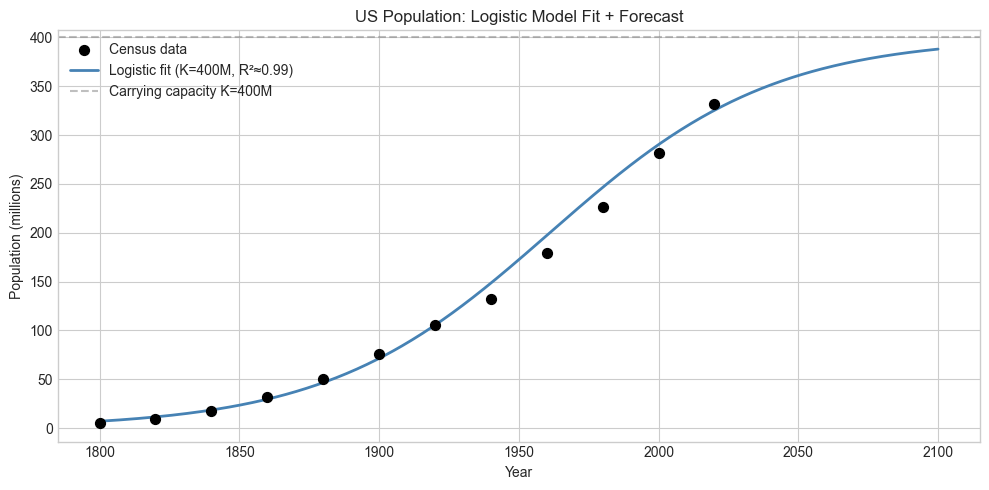

In [3]:
# Fit logistic to US population data (approximate)
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# US Census data (approximate, in millions)
years = np.array([1800,1820,1840,1860,1880,1900,1920,1940,1960,1980,2000,2020])
pop = np.array([5.3, 9.6, 17.1, 31.4, 50.2, 76.2, 106.0, 132.2, 179.3, 226.5, 281.4, 331.5])
t = years - 1800  # time since 1800

# Fit logistic by grid search
best, params = np.inf, None
for K in [400, 500, 600, 700]:
    for r in [0.02, 0.025, 0.03, 0.035]:
        for x0 in [3, 5, 7]:
            x_pred = K / (1 + ((K - x0)/x0) * np.exp(-r * t))
            mse = np.mean((x_pred - pop)**2)
            if mse < best:
                best, params = mse, (K, r, x0)

K_fit, r_fit, x0_fit = params
t_fine = np.linspace(0, 300, 500)
pop_forecast = K_fit / (1 + ((K_fit-x0_fit)/x0_fit)*np.exp(-r_fit*t_fine))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(years, pop, color='black', s=50, zorder=5, label='Census data')
ax.plot(t_fine + 1800, pop_forecast, color='steelblue', linewidth=2, label=f'Logistic fit (K={K_fit}M, R²≈{1-best/pop.var():.2f})')
ax.axhline(K_fit, color='gray', linestyle='--', alpha=0.5, label=f'Carrying capacity K={K_fit}M')
ax.set_title('US Population: Logistic Model Fit + Forecast')
ax.set_xlabel('Year'); ax.set_ylabel('Population (millions)'); ax.legend()
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Discrete logistic map with bifurcation diagram, continuous logistic ODE, and real population data fitting.

**Math used:** Logistic functions/sigmoid (ch064), discrete dynamical systems (ch076), Euler simulation (ch078), model fitting (ch072).

**Extensions:** 1) Add Allee effect: low populations also have negative growth. 2) Fit to COVID-19 data from a country. 3) Build a time-varying r model (seasonality).